# Decision Trees

1. Decision Trees (Classification)
    * They calcuate the Gini impurity(other metrics can be used, but they are similar to Gini impurity).
    * Create many trees for all discrete features. Find the gini for all of those trees and use the tree that has lowest gini impuirty.
    * Using the tree from the previous step, repeat until you have all leaf nodes.
    * If you numerical features, it works differently. Orgainize the numerical features in ascendcing order and find mean between each number. Create branch nodes from for each mean and consider the node that has the lowest Gini impurity.
    * You can prune and prevent overfitting by seting a min gini impurity, a required number of samples in a node for spliting,

🚩
Deliverable: Train a decision tree on the UCI Heart Disease dataset. Visualize it with plot_tree() at max_depth=3. Then use a validation curve to find the best ccp_alpha for pruning. Compare the pruned vs. unpruned tree's cross-val score and depth.

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  

y = (y>0).astype(int)


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split, validation_curve, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [5]:
len(X_train), len(X_test)

(227, 76)

In [6]:
full_tree  = DecisionTreeClassifier()
path  = full_tree.cost_complexity_pruning_path(X_train, y_train)

In [7]:
ccp_alphas = path.ccp_alphas[:-1]
ccp_alphas

array([0.        , 0.00286058, 0.00396476, 0.00403818, 0.00565617,
       0.00587372, 0.00587372, 0.00587372, 0.00660793, 0.00734214,
       0.00741943, 0.00783162, 0.00792952, 0.00806775, 0.00834335,
       0.00895742, 0.01667154, 0.01928491, 0.02128449, 0.02248403,
       0.03524969, 0.03669268])

In [8]:
len(ccp_alphas)

22

In [9]:
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(),
    X_train, y_train,
    param_name='ccp_alpha',
    param_range=ccp_alphas,
    cv=10,
    scoring='accuracy'
)

avg = val_scores.mean(axis=1)
best_aplha = ccp_alphas[np.argmax(avg)]
print(best_aplha)

0.00895741556534508


In [10]:
pruned_tree = DecisionTreeClassifier(ccp_alpha=best_aplha).fit(X_train, y_train)
unpruned_tree = DecisionTreeClassifier().fit(X_train, y_train)

In [11]:
print("Unpruned depth:", unpruned_tree.get_depth(), 
      "| CV score:", cross_val_score(unpruned_tree, X_train, y_train, cv=5, scoring='accuracy').mean())

print("Pruned depth:", pruned_tree.get_depth(), 
      "| CV score:", cross_val_score(pruned_tree, X_train, y_train, cv=5, scoring='accuracy').mean())

Unpruned depth: 9 | CV score: 0.722512077294686
Pruned depth: 4 | CV score: 0.7842512077294685


[Text(0.5769230769230769, 0.9, 'x[12] <= 4.5\ngini = 0.635\nsamples = 227\nvalue = [125.0, 43.0, 25.0, 25.0, 9.0]'),
 Text(0.3076923076923077, 0.7, 'x[11] <= 0.5\ngini = 0.339\nsamples = 121\nvalue = [97, 15, 5, 4, 0]'),
 Text(0.4423076923076923, 0.8, 'True  '),
 Text(0.15384615384615385, 0.5, 'x[3] <= 157.0\ngini = 0.174\nsamples = 85\nvalue = [77, 6, 2, 0, 0]'),
 Text(0.07692307692307693, 0.3, 'gini = 0.116\nsamples = 82\nvalue = [77, 4, 1, 0, 0]'),
 Text(0.23076923076923078, 0.3, 'gini = 0.444\nsamples = 3\nvalue = [0, 2, 1, 0, 0]'),
 Text(0.46153846153846156, 0.5, 'x[1] <= 0.5\ngini = 0.61\nsamples = 36\nvalue = [20, 9, 3, 4, 0]'),
 Text(0.38461538461538464, 0.3, 'gini = 0.296\nsamples = 18\nvalue = [15, 1, 1, 1, 0]'),
 Text(0.5384615384615384, 0.3, 'gini = 0.685\nsamples = 18\nvalue = [5, 8, 2, 3, 0]'),
 Text(0.8461538461538461, 0.7, 'x[9] <= 0.7\ngini = 0.778\nsamples = 106\nvalue = [28, 28, 20, 21, 9]'),
 Text(0.7115384615384615, 0.8, '  False'),
 Text(0.7692307692307693, 0.5, '

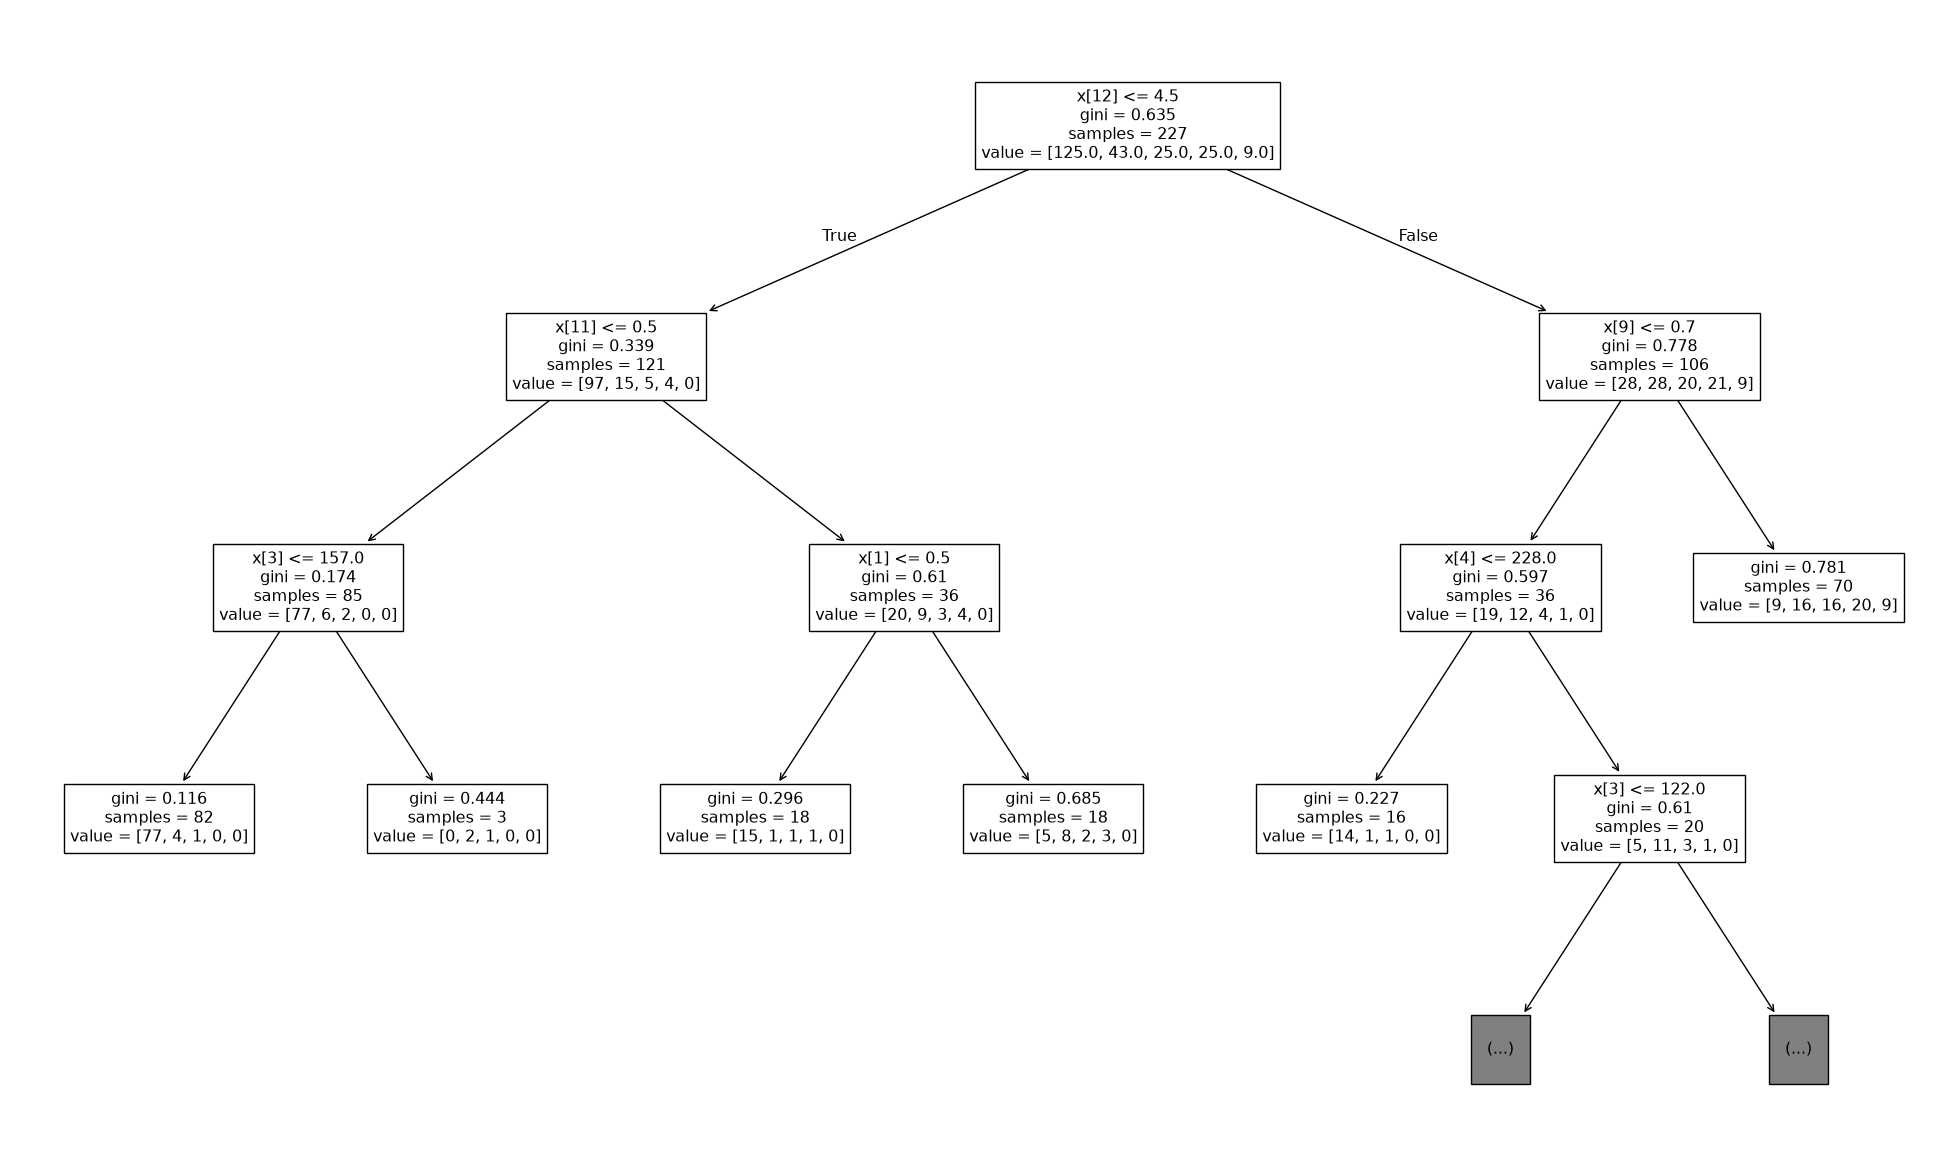

In [49]:
_, ax = plt.subplots(figsize=(25,15))
plot_tree(pruned_tree, max_depth=3, ax=ax)

In [12]:
y_pred = pruned_tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.8157894736842105